# Explorative Datenanalyse (EDA) – EuroSAT Datensatz
**Ziel:** Den EuroSAT-Datensatz verstehen – Verteilung der Klassen, Bildeigenschaften, Pixelstatistiken und Auffälligkeiten.

## 1. Importe & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from PIL import Image

plt.rcParams.update({'font.size': 12})
np.random.seed(42)

## 2. Datenpfad & Klassen

In [3]:
DATA_DIR = Path("../../data/original")

class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Anzahl der Klassen: {len(class_names)}")
print(f"Klassen: {class_names}")

Anzahl der Klassen: 10
Klassen: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [4]:
class_stats = []
for cls in class_names:
    cls_dir = DATA_DIR / cls
    files = list(cls_dir.glob("*"))
    class_stats.append({'Klasse': cls, 'Anzahl Bilder': len(files)})

df_stats = pd.DataFrame(class_stats)
df_stats

,Klasse,Anzahl Bilder
0,AnnualCrop,3000
1,Forest,3000
2,HerbaceousVegetation,3000
3,Highway,2500
4,Industrial,2500
5,Pasture,2000
6,PermanentCrop,2500
7,Residential,3000
8,River,2500
9,SeaLake,3000


**Beobachtung:** Die Anzahl der Bilder pro Klasse variiert zwischen 2000 und 3000. Der Datensatz ist **nicht vollständig balanciert**.

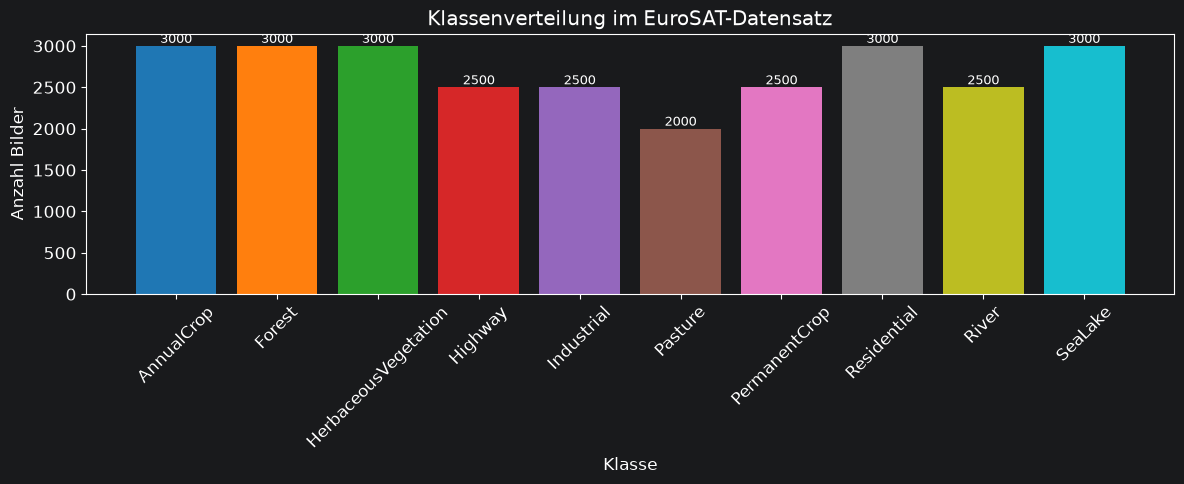

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(df_stats)))
bars = ax.bar(df_stats['Klasse'], df_stats['Anzahl Bilder'], color=colors)
ax.set_xlabel('Klasse')
ax.set_ylabel('Anzahl Bilder')
ax.set_title('Klassenverteilung im EuroSAT-Datensatz')
ax.tick_params(axis='x', rotation=45)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Bildabmessungen

In [6]:
sample_images = []
for cls in class_names:
    cls_dir = DATA_DIR / cls
    img_path = list(cls_dir.glob("*"))[0]
    sample_images.append(img_path)

dims = []
for img_path in sample_images:
    with Image.open(img_path) as img:
        dims.append(img.size)

df_dims = pd.DataFrame(dims, columns=['Breite', 'Höhe'], index=class_names)
df_dims

,Breite,Höhe
AnnualCrop,64,64
Forest,64,64
HerbaceousVegetation,64,64
Highway,64,64
Industrial,64,64
Pasture,64,64
PermanentCrop,64,64
Residential,64,64
River,64,64
SeaLake,64,64


**Ergebnis:** Alle Bilder haben einheitlich die Größe **64×64 Pixel** im RGB-Format.

## 4. Beispielbilder pro Klasse

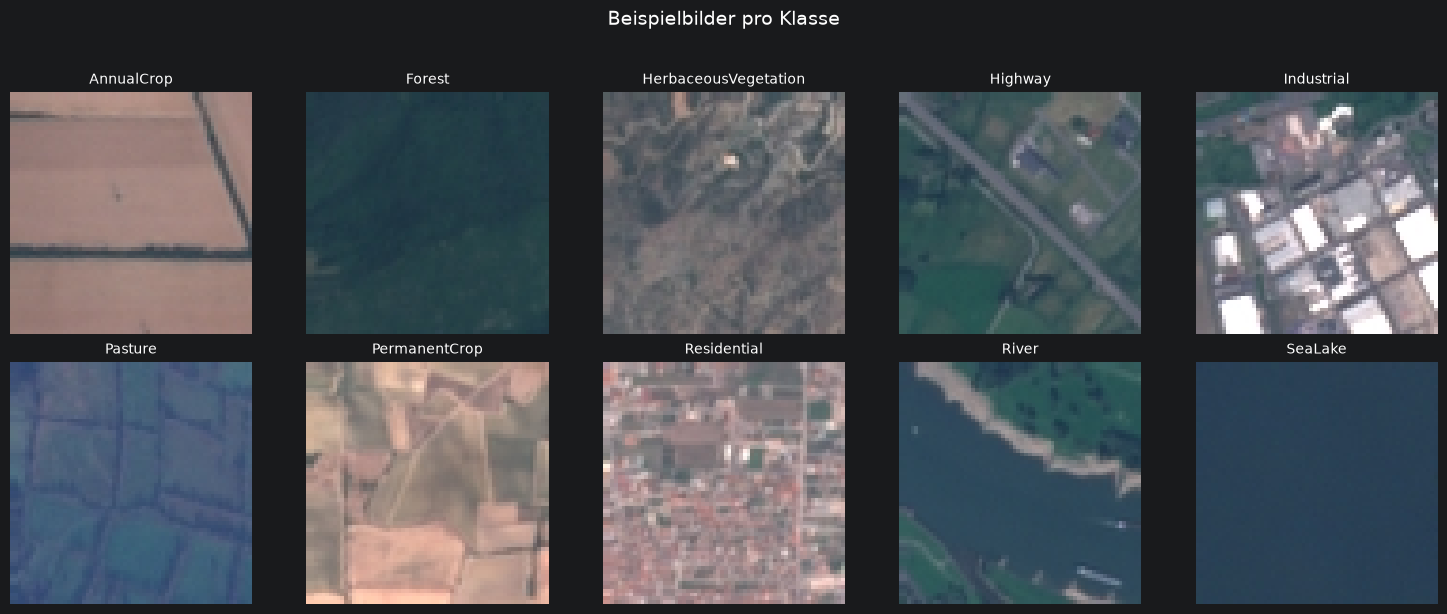

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, cls in enumerate(class_names):
    cls_dir = DATA_DIR / cls
    files = list(cls_dir.glob("*"))
    rand_img = np.random.choice(files)
    img = mpimg.imread(rand_img)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis('off')

fig.suptitle('Beispielbilder pro Klasse', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Pixel-Intensitätsverteilung (pro Farbkanal)

In [8]:
pixel_data = {cls: [] for cls in class_names}

for cls in class_names:
    cls_dir = DATA_DIR / cls
    files = list(cls_dir.glob("*"))
    sample = np.random.choice(files, min(100, len(files)), replace=False)
    for f in sample:
        img = np.array(Image.open(f))
        pixel_data[cls].append(img)

pixel_data = {k: np.concatenate([arr.reshape(-1, 3) for arr in v], axis=0) for k, v in pixel_data.items()}

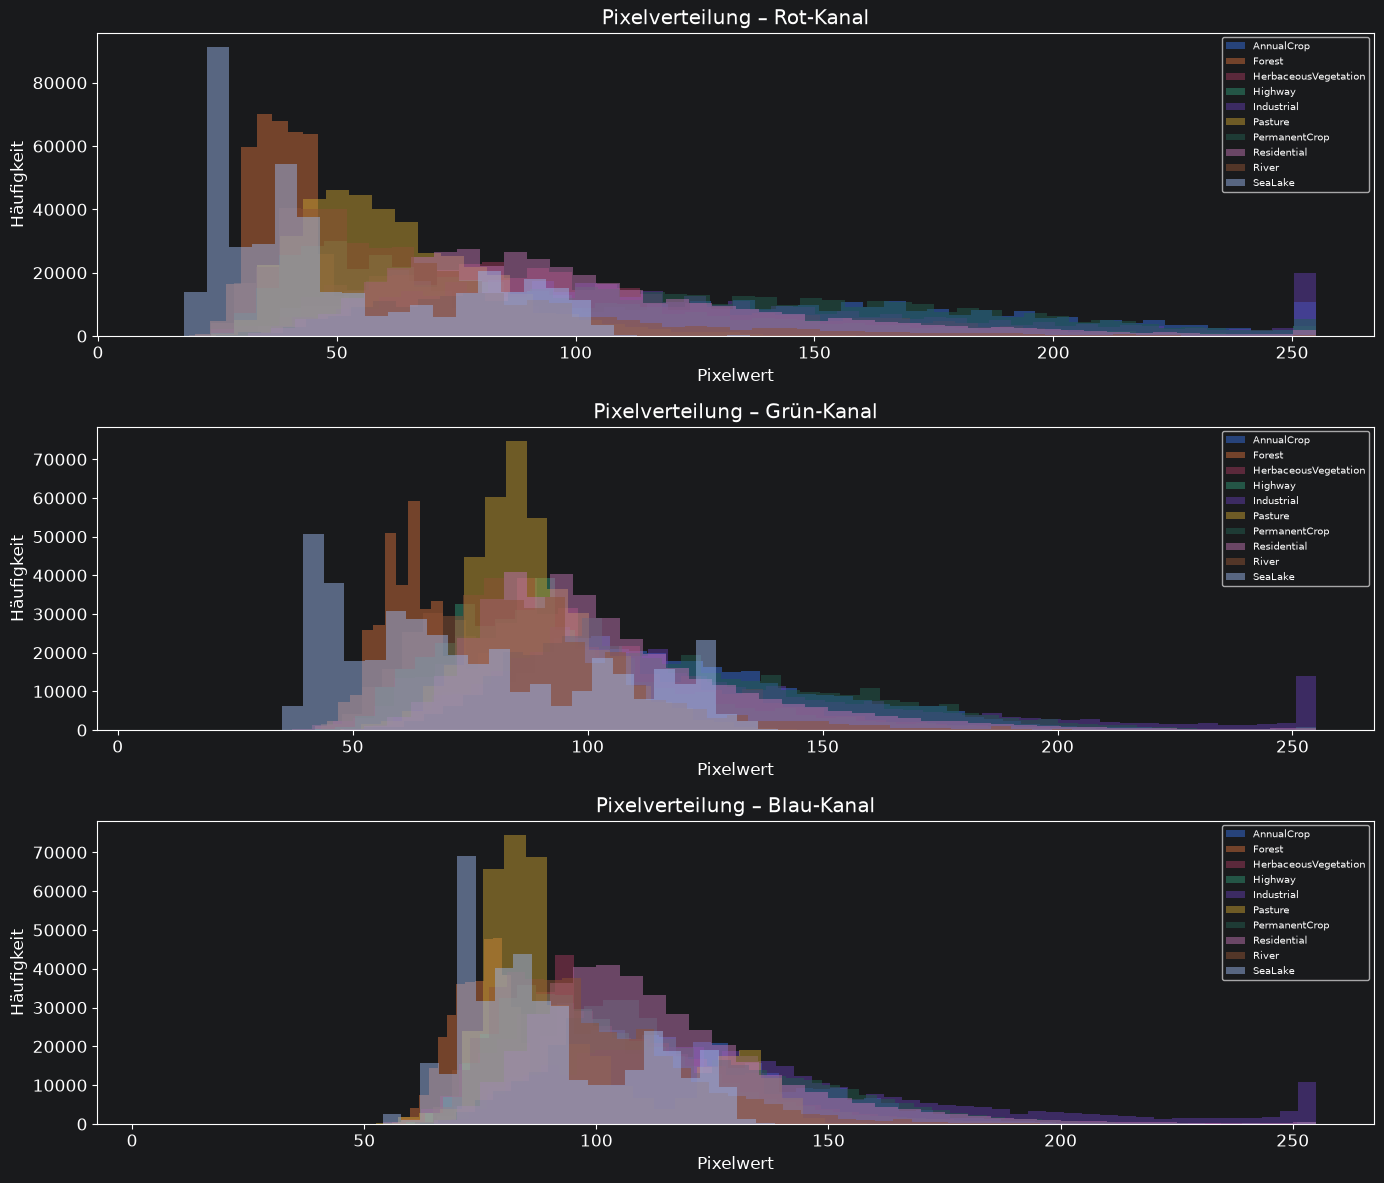

In [9]:
channel_names = ['Rot', 'Grün', 'Blau']
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ch_idx, ch_name in enumerate(channel_names):
    ax = axes[ch_idx]
    for cls in class_names:
        ax.hist(pixel_data[cls][:, ch_idx], bins=50, alpha=0.5, label=cls)
    ax.set_title(f'Pixelverteilung – {ch_name}-Kanal')
    ax.set_xlabel('Pixelwert')
    ax.set_ylabel('Häufigkeit')
    ax.legend(loc='upper right', fontsize=7)

plt.tight_layout()
plt.show()

In [10]:
class_means = {}
for cls in class_names:
    mean_rgb = pixel_data[cls].mean(axis=0)
    class_means[cls] = mean_rgb

df_means = pd.DataFrame(class_means, index=['Rot', 'Grün', 'Blau']).T
df_means.style.format("{:.1f}").background_gradient(cmap='Blues')

,Rot,Grün,Blau
AnnualCrop,125.1,117.8,115.6
Forest,39.9,65.5,76.5
HerbaceousVegetation,100.0,99.9,104.6
Highway,87.3,96.1,102.7
Industrial,123.7,125.6,134.0
Pasture,62.5,88.5,94.5
PermanentCrop,128.6,120.8,118.5
Residential,101.4,104.7,113.0
River,67.7,87.3,98.3
SeaLake,49.5,75.0,90.2


**Beobachtung:** Die mittleren Pixelintensitäten unterscheiden sich je nach Klasse – z.B. sind Wasserklassen (SeaLake, River) im Blaukanal tendenziell heller, während Vegetationsklassen (Forest, HerbaceousVegetation) höhere Grünwerte aufweisen.

## 6. Durchschnittsbild pro Klasse

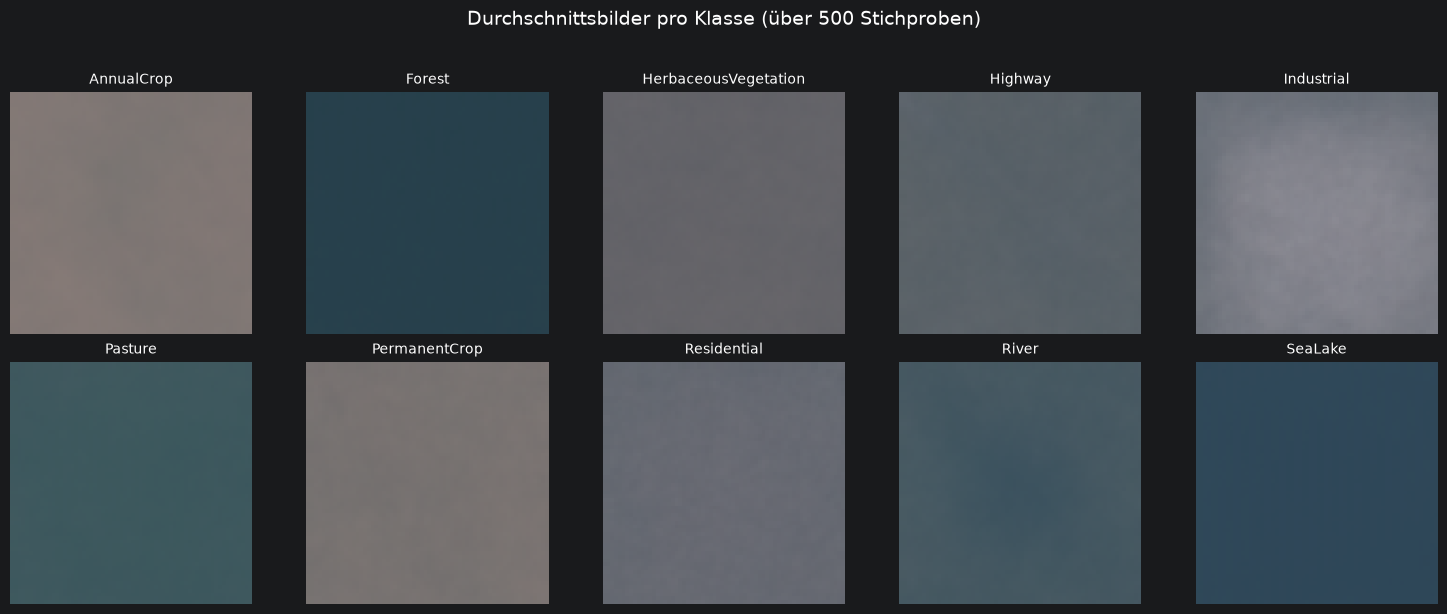

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, cls in enumerate(class_names):
    cls_dir = DATA_DIR / cls
    files = list(cls_dir.glob("*"))
    sample_files = np.random.choice(files, min(500, len(files)), replace=False)
    accum = np.zeros((64, 64, 3), dtype=np.float64)
    for f in sample_files:
        accum += np.array(Image.open(f), dtype=np.float64)
    mean_img = (accum / len(sample_files)).astype(np.uint8)
    axes[i].imshow(mean_img)
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis('off')

fig.suptitle('Durchschnittsbilder pro Klasse (über 500 Stichproben)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Erkenntnis:** Die Durchschnittsbilder zeigen deutlich die charakteristischen Farb- und Texturmuster jeder Klasse – z.B. dunkle Blautöne bei Wasserflächen, Grün bei Wäldern, Grau/Braun bei urbanen Gebieten.

## 7. Standardabweichung (Kontrast) pro Klasse

In [12]:
class_std = {}
for cls in class_names:
    class_std[cls] = pixel_data[cls].std(axis=0)

df_std = pd.DataFrame(class_std, index=['Rot', 'Grün', 'Blau']).T
df_std.style.format("{:.1f}").background_gradient(cmap='Oranges')

,Rot,Grün,Blau
AnnualCrop,58.7,31.8,25.6
Forest,8.3,10.2,9.0
HerbaceousVegetation,43.4,29.6,25.0
Highway,47.1,29.9,25.3
Industrial,56.0,46.0,42.1
Pasture,20.1,13.4,20.2
PermanentCrop,51.3,34.5,27.4
Residential,40.9,29.7,26.6
River,33.5,23.5,20.7
SeaLake,25.8,27.9,18.4


**Interpretation:** Eine hohe Standardabweichung deutet auf mehr Varianz im Bild hin (strukturreiche Szenen wie Industrie- oder Wohngebiete), während niedrige Werte auf homogenere Flächen hindeuten (z.B. Wasser oder Ackerland).

## 8. Zusammenfassung
| Merkmal | Wert |
|---|---|
| Anzahl Klassen | 10 |
| Gesamtanzahl Bilder | 27.000 |
| Bildgröße | 64×64 Pixel, RGB |
| Klassenverteilung | ungleichmäßig (2000–3000 Bilder/Klasse) |
| Dateiformat | JPEG |

**Wichtigste Erkenntnisse für das Modelltraining:**
- Die Klassen sind nicht perfekt balanciert – ggf. Stratified Sampling oder Class Weights verwenden.
- Die Pixelintensitätsverteilung unterscheidet sich deutlich zwischen den Klassen – hilfreich für die Klassifikation.
- Die Bilder haben eine niedrige Auflösung (64×64), was Transfer Learning mit Modellen wie MobileNetV3 (224×224 Input) erfordert.